# Regressão:

Problemas de regressão tratam-se de situção em que se deseja estimar o valor de uma varíavel continua a partir de um conjunto de métricas. 



**Agloritmos do experimento:**

* Decision Tree
* Random Forest
* Linear Regression
* Knn Regression
* Lr lasso
* Lr ridge
* Lr Elastic Net
* Polinomial Regression
* XGBoost

In [8]:
from sklearn.tree         import DecisionTreeRegressor     as dtr 
from sklearn.ensemble     import RandomForestRegressor     as rfr 
from sklearn.linear_model import LinearRegression          as lr 
from sklearn.linear_model import Ridge                     as rg 
from sklearn.linear_model import Lasso                     as ls
from sklearn.linear_model import ElasticNet                as en 
from sklearn.neighbors    import KNeighborsRegressor       as knr
from sklearn.metrics      import mean_absolute_error       as mae
from sklearn.metrics      import root_mean_squared_error   as rmse
from sklearn.metrics      import r2_score                  as r2
from sklearn.metrics      import mean_absolute_percentage_error as mape


#from sklearn.ensemble     import GradientBoostingRegressor as gbr

# Dataset: 


In [4]:
import pandas as pd
import sys 
sys.path.append('../../libs/src')

from data_utils import normalizer   


X_dataset = {}
X_dataset['training'] = pd.read_csv('../data/X_training.csv')
X_dataset['test'] = pd.read_csv('../data/X_test.csv') 
X_dataset['validation'] = pd.read_csv('../data/X_validation.csv')

y_dataset = {}
y_dataset['training'] = pd.read_csv('../data/y_training.csv')
y_dataset['test'] = pd.read_csv('../data/y_test.csv') 
y_dataset['validation'] = pd.read_csv('../data/y_validation.csv')

In [5]:
X_normalized_dataset = {}
y_normalized_dataset = {}
normalizador = normalizer(X_dataset['training'],
                          strategy = 'minMaxScaller')
for k in X_dataset.keys():
    X_normalized_dataset[k] = normalizador.getDfcolumnNormalized(X_dataset[k])



#### Normalizacao de y depende de avaliação da sua distribuição

In [6]:
y_dataset['training'].describe()

,song_popularity
count,10547.000000
mean,53.046961
std,21.864535
min,0.100000
25%,40.000000
50%,56.000000
75%,69.000000
max,100.000000


array([[<Axes: title={'center': 'song_popularity'}>]], dtype=object)

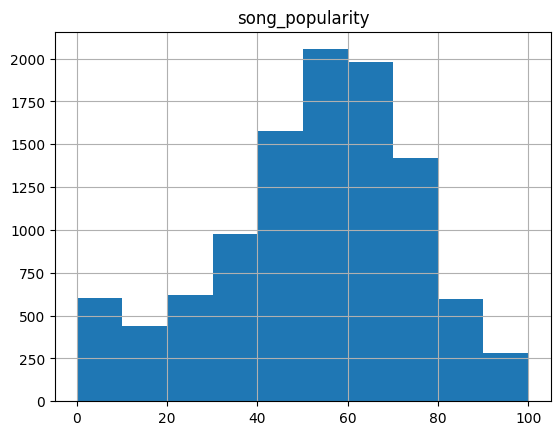

In [7]:
y_dataset['training'].hist()

# Treinando os modelos

## 2.1 - Modelos Lineares

### 2.1.1 - Regressão linear

In [13]:
linearRegressor = lr()
linearRegressor.fit(X_normalized_dataset['training'], 
                    y_dataset['training'])
y_predicted = linearRegressor.predict(X_normalized_dataset['test'])
print('MAE  :', mae(y_dataset['test'], y_predicted))
print('RMSE :', rmse(y_dataset['test'], y_predicted))
print('R2   :', r2(y_dataset['test'], y_predicted))
print('MAPE :', mape(y_dataset['test'], y_predicted))   

MAE  : 17.12996509166612
RMSE : 21.480868682071254
R2   : 0.052317119521687494
MAPE : 8.521859277849835


### 2.1.2 Regressão linear l1 - lasso 

### 2.1.3 - Regressão Linear l2 - ridge

### 2.1.4 - Regressão Linear l1 + l2 - elasticNet

In [ ]:
## 

## 2.2 Modelos mais complexos (lineares ou não)

### 2.2.1 - Decision Tree

In [11]:
decisionTreeRegressor = dtr(max_depth=30)
decisionTreeRegressor.fit(X_normalized_dataset['training'], 
                          y_dataset['training'])

y_predicted = decisionTreeRegressor.predict(X_normalized_dataset['test'])
print('MAE  :', mae(y_dataset['test'], y_predicted))
print('RMSE :', rmse(y_dataset['test'], y_predicted))
print('R2   :', r2(y_dataset['test'], y_predicted))
print('MAPE :', mape(y_dataset['test'], y_predicted))

MAE  : 17.000783116538358
RMSE : 24.66257040246208
R2   : -0.2492116651609113
MAPE : 6.288514393760408


### 2.2.2 - RandomForest

In [12]:
randomForestRegressor = rfr(n_estimators=100, 
                            max_depth=30)

randomForestRegressor.fit(X_normalized_dataset['training'], 
                          y_dataset['training'])    

y_predicted = randomForestRegressor.predict(X_normalized_dataset['test'])
print('MAE  :', mae(y_dataset['test'], y_predicted))
print('RMSE :', rmse(y_dataset['test'], y_predicted))
print('R2   :', r2(y_dataset['test'], y_predicted))
print('MAPE :', mape(y_dataset['test'], y_predicted))

/home/p123/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 13.043094364903355
RMSE : 17.766265349209757
R2   : 0.35173638975880916
MAPE : 6.546591296072289


### 2.2.3 KNN